# Video Swin Transformer - Basketball-51 Reproduction

Trains the **Video Swin Transformer** ([Liu et al., CVPR 2022](https://arxiv.org/abs/2106.13230); code: [SwinTransformer/Video-Swin-Transformer](https://github.com/SwinTransformer/Video-Swin-Transformer)) on the Basketball-51 dataset.

The implementation wraps the official torchvision port of the architecture (`torchvision.models.video.swin3d_{t,s,b}`) and initializes from the Kinetics-400 pretrained weights. Training follows the paper's Section 4.1 recipe (AdamW, cosine LR with 2.5-epoch linear warmup, backbone LR = 0.1x head LR, label smoothing 0.1, 32 frames @ 224x224).

Dataset splits are built once (seeded stratified 80/10/10) and reused across all training, validation, and evaluation runs so numbers are directly comparable.

This notebook expects:\n- The dataset zipped to a single archive on Drive at `DATA_ZIP`. Inside the zip, the layout must be `Basketball-51/{2p0,2p1,3p0,3p1,ft0,ft1,mp0,mp1}/*.mp4`. The zip is unpacked into `/content` (Colab local disk) for fast I/O.

## 1. Mount Drive and set paths

In [ ]:
import os
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

Mounted at /content/drive


In [ ]:
REPO_DIR = Path('/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test' if IN_COLAB else '.')
DATA_ZIP = Path('/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Datasets/Basketball_51 dataset.zip' if IN_COLAB else 'Basketball-51.zip')
# DATA_ROOT is the unzipped local-disk location; fast I/O vs the Drive FUSE mount.
DATA_ROOT = Path('/content/Basketball-51' if IN_COLAB else 'Basketball-51')
RUNS_ROOT = Path('/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs' if IN_COLAB else './runs')
SPLITS_JSON = Path('/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/splits.json' if IN_COLAB else './splits.json')

RUNS_ROOT.mkdir(parents=True, exist_ok=True)
print('REPO_DIR :', REPO_DIR)
print('DATA_ZIP :', DATA_ZIP)
print('DATA_ROOT:', DATA_ROOT)
print('RUNS_ROOT:', RUNS_ROOT)
print('SPLITS   :', SPLITS_JSON)

REPO_DIR : /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test
DATA_ZIP : /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Datasets/Basketball_51 dataset.zip
DATA_ROOT: /content/Basketball-51
RUNS_ROOT: /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs
SPLITS   : /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/splits.json


## 2. Install dependencies and the package

`pip install -e .` from the repo installs the `videoswin` package in editable mode.

In [ ]:
%cd $REPO_DIR
!pip install -q -e .
!pip install -q decord opencv-python
import torch, torchvision
print('torch       :', torch.__version__, 'cuda:', torch.cuda.is_available())
print('torchvision :', torchvision.__version__)
if torch.cuda.is_available():
    print('device      :', torch.cuda.get_device_name(0))

# Sanity-check that torchvision is new enough to expose swin3d_*.
from torchvision.models import video as tv_video
assert hasattr(tv_video, 'swin3d_t'), (
    'torchvision.models.video.swin3d_t is missing. '
    'Upgrade torchvision: `pip install -U torchvision`.'
)
print('torchvision has swin3d_t/s/b : OK')

/content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 137.5 MB/s eta 0:00:00
torch       : 2.10.0+cu128 cuda: True
torchvision : 0.25.0+cu128
device      : Tesla T4
torchvision has swin3d_t/s/b : OK


## 2.5. Stage the dataset on local disk (fast I/O)

Unzips the Basketball-51 archive from Drive to `/content` (Colab local disk) for faster epoch-time I/O. If `/content/Basketball-51` already exists from a previous run on this Colab VM, the cell detects it and skips the copy/unzip.

In [ ]:
import shutil, subprocess, time, zipfile

EXPECTED_CLASSES = ('2p0', '2p1', '3p0', '3p1', 'ft0', 'ft1', 'mp0', 'mp1')

def _has_all_classes(root):
    return root.is_dir() and all((root / c).is_dir() for c in EXPECTED_CLASSES)

def _find_class_root(base):
    if _has_all_classes(base):
        return base
    for cur in base.rglob('*'):
        if not cur.is_dir():
            continue
        parts = cur.relative_to(base).parts
        if any(p.startswith('.') or p == '__MACOSX' for p in parts):
            continue
        if _has_all_classes(cur):
            return cur
    return None

if _has_all_classes(DATA_ROOT):
    n_files = sum(1 for _ in DATA_ROOT.rglob('*') if _.is_file())
    print(f'Dataset already staged at {DATA_ROOT} ({n_files} files). Skipping.')
else:
    if not DATA_ZIP.exists():
        raise FileNotFoundError(
            f'DATA_ZIP not found: {DATA_ZIP}\nUpload the dataset zip to Drive at that path, or edit DATA_ZIP in cell 1.'
        )

    local_zip = Path('/content') / DATA_ZIP.name
    if not local_zip.exists() or local_zip.stat().st_size != DATA_ZIP.stat().st_size:
        size_gb = DATA_ZIP.stat().st_size / (1024 ** 3)
        print(f'Copying {DATA_ZIP.name} ({size_gb:.2f} GB) from Drive to {local_zip} ...')
        t0 = time.time()
        shutil.copyfile(DATA_ZIP, local_zip)
        print(f'Copy done in {time.time() - t0:.1f}s')
    else:
        print(f'Local zip already present at {local_zip}, skipping copy.')

    staging = Path('/content/_b51_extract_tmp')
    if staging.exists():
        shutil.rmtree(staging)
    staging.mkdir(parents=True)

    print(f'Unzipping into {staging} ...')
    t0 = time.time()
    rc = subprocess.call(['unzip', '-q', '-o', str(local_zip), '-d', str(staging)])
    if rc != 0:
        print('Falling back to Python zipfile...')
        with zipfile.ZipFile(local_zip) as zf:
            zf.extractall(staging)
    print(f'Unzip done in {time.time() - t0:.1f}s')

    class_root = _find_class_root(staging)
    if class_root is None:
        raise RuntimeError(
            f'Could not locate the 8 class folders in {staging}. '
            f'Expected names: {EXPECTED_CLASSES}. '
            f'Top-level: {sorted(p.name for p in staging.iterdir())}'
        )
    print(f'Detected class root inside archive: {class_root}')

    if DATA_ROOT.exists():
        shutil.rmtree(DATA_ROOT)
    DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)
    shutil.move(str(class_root), str(DATA_ROOT))

    shutil.rmtree(staging, ignore_errors=True)
    try:
        local_zip.unlink()
    except OSError:
        pass

    if not _has_all_classes(DATA_ROOT):
        raise RuntimeError(
            f'After staging, {DATA_ROOT} is missing some of the expected class folders {EXPECTED_CLASSES}.'
        )
    n_files = sum(1 for _ in DATA_ROOT.rglob('*') if _.is_file())
    print(f'Dataset ready at {DATA_ROOT} ({n_files} files).')

Copying Basketball_51 dataset.zip (6.02 GB) from Drive to /content/Basketball_51 dataset.zip ...
Copy done in 66.7s
Unzipping into /content/_b51_extract_tmp ...
Unzip done in 54.1s
Detected class root inside archive: /content/_b51_extract_tmp/Basketball_51 dataset
Dataset ready at /content/Basketball-51 (10311 files).


## 3. Build (or reuse) the 80/10/10 split

Reuses the `splits.json` if it already exists so the two reproductions train/test on identical clips.

In [ ]:
from videoswin.data import make_splits, save_splits, load_splits

if SPLITS_JSON.exists():
    splits = load_splits(SPLITS_JSON)
    print('splits.json already exists at', SPLITS_JSON)
else:
    splits = make_splits(DATA_ROOT, train_ratio=0.8, val_ratio=0.1, seed=42)
    save_splits(splits, SPLITS_JSON)
    print('Created new splits.json at', SPLITS_JSON)

for name in ('train', 'val', 'test'):
    print(f'{name}: {len(splits[name])} clips')

splits.json already exists at /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/splits.json
train: 8248 clips
val: 1031 clips
test: 1032 clips


## 4. Sanity check: forward pass



In [ ]:
import torch
from videoswin.models import build_video_swin, count_parameters

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Small spatial size so the smoke test also works on CPU if needed.
x = torch.randn(1, 3, 32, 224, 224, device=device)
for variant in ('scratch', 'tiny', 'small', 'base'):
    m = build_video_swin(num_classes=8, variant=variant).to(device).eval()
    with torch.no_grad():
        y = m(x)
    print(f'{variant:>8s}  out={tuple(y.shape)}  params={count_parameters(m)/1e6:.2f}M')
    del m
    if device == 'cuda':
        torch.cuda.empty_cache()

 scratch  out=(1, 8)  params=28.16M
Downloading: "https://download.pytorch.org/models/swin3d_t-7615ae03.pth" to /root/.cache/torch/hub/checkpoints/swin3d_t-7615ae03.pth


100%|██████████| 122M/122M [00:00<00:00, 220MB/s]


    tiny  out=(1, 8)  params=28.16M
Downloading: "https://download.pytorch.org/models/swin3d_s-da41c237.pth" to /root/.cache/torch/hub/checkpoints/swin3d_s-da41c237.pth


100%|██████████| 218M/218M [00:03<00:00, 66.3MB/s]


   small  out=(1, 8)  params=49.82M
Downloading: "https://download.pytorch.org/models/swin3d_b_22k-7c6ae6fa.pth" to /root/.cache/torch/hub/checkpoints/swin3d_b_22k-7c6ae6fa.pth


100%|██████████| 364M/364M [00:05<00:00, 69.6MB/s]


    base  out=(1, 8)  params=88.06M


## 5. Train + evaluate


In [ ]:
VARIANT = 'base'  # scratch | tiny | small | base


MICRO_BATCH_A100_40GB = {'scratch': 8, 'tiny': 8, 'small': 8, 'base': 6}
MICRO_BATCH_A100_80GB = {'scratch': 32, 'tiny': 32, 'small': 24, 'base': 16}
MICRO_BATCH_L4_24GB   = {'scratch': 4, 'tiny': 4,  'small': 2,  'base': 2}

MICRO_BATCH_TABLE = MICRO_BATCH_A100_40GB
MICRO_BATCH = MICRO_BATCH_TABLE[VARIANT]

EFFECTIVE_BATCH = 18

import os
os.environ['VARIANT'] = VARIANT
os.environ['RUN_DIR'] = str(RUNS_ROOT / VARIANT)
os.environ['MICRO_BATCH']     = str(MICRO_BATCH)
os.environ['EFFECTIVE_BATCH'] = str(EFFECTIVE_BATCH)
accum = max(1, EFFECTIVE_BATCH // MICRO_BATCH)
print(f'Training {VARIANT}: micro_batch={MICRO_BATCH}, effective_batch={EFFECTIVE_BATCH} '
      f'({accum}x gradient accumulation)')
!python -m videoswin.run_ablation \
    --data-root "$DATA_ROOT" \
    --splits "$SPLITS_JSON" \
    --runs-root "$RUNS_ROOT" \
    --variants $VARIANT \
    --num-frames 32 \
    --image-h 224 --image-w 224 \
    --effective-batch-size $EFFECTIVE_BATCH --micro-batch-size $MICRO_BATCH \
    --epochs 30 --patience 5 \
    --head-lr 3e-4 --backbone-lr-ratio 0.1 \
    --lr-schedule cosine --warmup-epochs 2.5 --min-lr-ratio 0.01 \
    --label-smoothing 0.1 \
    --num-workers 8 --seed 42 \
    --log-every 25 \
    --skip-if-exists

### 5b. Quick inspection of the most recent run

In [ ]:
import json

K400_REF = {'scratch': 76.6, 'tiny': 78.8, 'small': 80.6, 'base': 82.7}
run_dir = RUNS_ROOT / VARIANT

hist_path = run_dir / 'history.json'
if hist_path.exists():
    hist = json.loads(hist_path.read_text())
    print(f'--- {VARIANT}: last {min(len(hist), 8)} epochs ---')
    print(f"{'ep':>3s}  {'tr_loss':>8s}  {'tr_acc':>7s}  {'val_loss':>8s}  {'val_acc':>7s}  {'grad':>6s}  {'sec':>5s}")
    for r in hist[-8:]:
        print(f"{int(r['epoch']):>3d}  {r['train_loss']:>8.4f}  {r['train_acc']:>7.4f}  "
              f"{r['val_loss']:>8.4f}  {r['val_acc']:>7.4f}  "
              f"{r.get('grad_norm_last', float('nan')):>6.2f}  "
              f"{r.get('epoch_seconds', 0.0):>5.1f}")
    best = max(hist, key=lambda r: r['val_acc'])
    print(f"\nBest val_acc: {best['val_acc']*100:.2f}% at epoch {best['epoch']}")
else:
    print(f'No history.json yet at {hist_path}.')

results_path = run_dir / 'results.json'
if results_path.exists():
    res = json.loads(results_path.read_text())
    m = res['metrics']
    k400 = K400_REF.get(VARIANT, float('nan'))
    ours = m['accuracy'] * 100
    print(f"\n--- {VARIANT}: test metrics on Basketball-51 ---")
    print(f"  accuracy      : {ours:6.2f}%   (paper K400 ref {k400:6.2f}% - different dataset, shown for context only)")
    print(f"  precision_mac : {m['precision_macro']*100:6.2f}%")
    print(f"  recall_mac    : {m['recall_macro']*100:6.2f}%")
    print(f"  f1_macro      : {m['f1_macro']*100:6.2f}%")
    print(f"  auc_ovr_macro : {m['auc_ovr_macro']*100:6.2f}%")
else:
    print(f'\nNo results.json yet at {results_path} (eval has not run for this variant).')

--- base: last 8 epochs ---
 ep   tr_loss   tr_acc  val_loss  val_acc    grad    sec
 20    0.7772   0.8588    0.5650   0.8080   16.08  654.4
 21    0.7682   0.8639    0.5538   0.8128    4.87  655.2
 22    0.7637   0.8705    0.5426   0.8109    6.46  655.4
 23    0.7445   0.8809    0.5422   0.8215   14.17  654.9
 24    0.7347   0.8829    0.5233   0.8206   10.19  654.8
 25    0.7340   0.8861    0.5341   0.8167   15.65  654.6
 26    0.7178   0.8941    0.5321   0.8186   18.28  655.5
 27    0.7191   0.8939    0.5355   0.8157    8.58  656.5

Best val_acc: 82.15% at epoch 23

No results.json yet at /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/base/results.json (eval has not run for this variant).


## 7. Collate final results table

In [ ]:
import json
import pandas as pd

K400_REF = {'scratch': 76.6, 'tiny': 78.8, 'small': 80.6, 'base': 82.7}

rows = []
for variant in ('scratch', 'tiny', 'small', 'base'):
    results_file = RUNS_ROOT / variant / 'results.json'
    if not results_file.exists():
        rows.append({'variant': variant, 'status': 'missing'})
        continue
    with results_file.open() as f:
        m = json.load(f)['metrics']
    row = {
        'variant': variant,
        'accuracy': m['accuracy'] * 100,
        'precision_macro': m['precision_macro'] * 100,
        'recall_macro': m['recall_macro'] * 100,
        'f1_macro': m['f1_macro'] * 100,
        'auc_ovr_macro': m['auc_ovr_macro'] * 100,
        'k400_ref_acc': K400_REF[variant],
    }
    rows.append(row)

df = pd.DataFrame(rows)
display(df.round(2))
df.to_csv(RUNS_ROOT / 'ablation_table.csv', index=False)

## 8. Inspect figures and generate report

Confusion matrix + t-SNE figures are produced during eval for the flagship variant (default: `base`). `videoswin.report` collates everything into a markdown report.

## 9. Evaluation on the best checkpoint

In [ ]:
import json
from pathlib import Path

import numpy as np
import torch

from videoswin import BASKETBALL51_CLASSES
from videoswin.data import (
    Basketball51Dataset,
    VideoEval,
    load_splits,
    worker_init_fn,
)
from videoswin.eval import collect_predictions
from videoswin.models import build_video_swin
from videoswin.utils import load_checkpoint
from torch.utils.data import DataLoader

try:
    VARIANT
except NameError:
    VARIANT = 'base'

RUN_DIR        = RUNS_ROOT / VARIANT
CKPT_PATH      = RUN_DIR / 'best.pt'
REPORT_DIR     = RUN_DIR / 'eval_report'
PREDICTIONS_NPZ = REPORT_DIR / 'raw_predictions.npz'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

assert CKPT_PATH.exists(), f'No best checkpoint found at {CKPT_PATH}. Train the flagship variant first.'

EVAL_SPLIT   = 'test'
EVAL_BATCH   = 4
NUM_WORKERS  = 8
USE_AMP      = True
FORCE_REBUILD = False

if PREDICTIONS_NPZ.exists() and not FORCE_REBUILD:
    print(f'Loading cached predictions from {PREDICTIONS_NPZ}')
    npz = np.load(PREDICTIONS_NPZ, allow_pickle=False)
    logits   = npz['logits']
    labels   = npz['labels']
    features = npz['features']
    sample_paths = [Path(p).as_posix() for p in npz['sample_paths']]
else:
    splits = load_splits(SPLITS_JSON)
    eval_samples = splits[EVAL_SPLIT]
    sample_paths = [str(Path(DATA_ROOT) / cls) for cls, name in eval_samples]

    dataset = Basketball51Dataset(
        root=DATA_ROOT,
        samples=eval_samples,
        transform=VideoEval(out_h=224, out_w=224),
        num_frames=32,
        temporal_jitter=False,
    )
    loader = DataLoader(
        dataset,
        batch_size=EVAL_BATCH,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=worker_init_fn if NUM_WORKERS > 0 else None,
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = build_video_swin(num_classes=len(BASKETBALL51_CLASSES), variant=VARIANT).to(device)
    load_checkpoint(CKPT_PATH, model, map_location=device)
    model.eval()

    out = collect_predictions(model, loader, device, amp=USE_AMP, collect_features=True)
    logits   = out['logits']
    labels   = out['labels']
    features = out['features']

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    np.savez_compressed(
        PREDICTIONS_NPZ,
        logits=logits.astype(np.float32),
        labels=labels.astype(np.int64),
        features=features.astype(np.float32),
        sample_paths=np.array(sample_paths),
    )
    print(f'Cached raw predictions at {PREDICTIONS_NPZ} ({PREDICTIONS_NPZ.stat().st_size/1e6:.1f} MB)')

def _softmax(x, axis=1):
    x = x - x.max(axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=axis, keepdims=True)

probs = _softmax(logits, axis=1)
preds = logits.argmax(axis=1)

N = logits.shape[0]
overall_acc = (preds == labels).mean()
print(f'\nSplit            : {EVAL_SPLIT}')
print(f'Samples          : {N}')
print(f'Variant          : {VARIANT}')
print(f'Logits shape     : {logits.shape}')
print(f'Features shape   : {features.shape}  (per-clip backbone embedding)')
print(f'Top-1 accuracy   : {overall_acc*100:6.2f}%')

Loading cached predictions from /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/base/eval_report/raw_predictions.npz

Split            : test
Samples          : 1032
Variant          : base
Logits shape     : (1032, 8)
Features shape   : (1032, 1024)  (per-clip backbone embedding)
Top-1 accuracy   :  82.66%


## 10. Basketball-aware class taxonomy

The 8 Basketball-51 classes are a Cartesian product of **shot type** and **outcome**:

| Class | Basketball meaning                                 | Points if made |
|-------|----------------------------------------------------|:--------------:|
| `ft0` | Free throw — missed                                |       0        |
| `ft1` | Free throw — made                                  |       1        |
| `2p0` | 2-point attempt (layup / drive / close-range) — missed |   0        |
| `2p1` | 2-point attempt — made                             |       2        |
| `mp0` | Mid-range pull-up jumper — missed                  |       0        |
| `mp1` | Mid-range pull-up jumper — made                    |       2        |
| `3p0` | 3-point attempt — missed                           |       0        |
| `3p1` | 3-point attempt — made                             |       3        |

This lets us evaluate the model at three semantically different granularities:

- **Shot-type recognition** (4-way): does the model understand the *type* of attempt (2-pt vs 3-pt vs FT vs mid-range)? This is the harder, more action-content question.
- **Outcome recognition** (binary): can it tell if the ball went in? Strongly cued by short-horizon frames at the end of the clip.
- **Expected-points regression**: treat each clip's true points as the ground-truth scalar target, and the model's softmax-weighted points expectation as the prediction. An interpretable scoreboard-level error.

In [ ]:
CLASS_NAMES = list(BASKETBALL51_CLASSES)
N_CLASSES   = len(CLASS_NAMES)

SHOT_TYPE_OF   = {'ft0':'ft', 'ft1':'ft', '2p0':'2p', '2p1':'2p', 'mp0':'mp', 'mp1':'mp', '3p0':'3p', '3p1':'3p'}
OUTCOME_OF     = {c: ('make' if c.endswith('1') else 'miss') for c in CLASS_NAMES}
POINTS_OF      = {'ft0':0, 'ft1':1, '2p0':0, '2p1':2, 'mp0':0, 'mp1':2, '3p0':0, '3p1':3}
HUMAN_LABEL_OF = {
    'ft0': 'Free throw — missed',
    'ft1': 'Free throw — made',
    '2p0': '2-pt attempt — missed',
    '2p1': '2-pt attempt — made',
    'mp0': 'Mid-range pull-up — missed',
    'mp1': 'Mid-range pull-up — made',
    '3p0': '3-pt attempt — missed',
    '3p1': '3-pt attempt — made',
}

SHOT_TYPES = ('ft', '2p', 'mp', '3p')
OUTCOMES   = ('miss', 'make')

SHOT_TYPE_IDX = {name: i for i, name in enumerate(SHOT_TYPES)}
OUTCOME_IDX   = {name: i for i, name in enumerate(OUTCOMES)}

points_vec = np.array([POINTS_OF[c] for c in CLASS_NAMES], dtype=np.float32)
shot_type_id_per_class = np.array([SHOT_TYPE_IDX[SHOT_TYPE_OF[c]] for c in CLASS_NAMES], dtype=np.int64)
outcome_id_per_class   = np.array([OUTCOME_IDX[OUTCOME_OF[c]]     for c in CLASS_NAMES], dtype=np.int64)

true_shot_type = shot_type_id_per_class[labels]
pred_shot_type = shot_type_id_per_class[preds]
true_outcome   = outcome_id_per_class[labels]
pred_outcome   = outcome_id_per_class[preds]

true_points = points_vec[labels]
pred_points = points_vec[preds]

probs_shot_type = np.zeros((N, len(SHOT_TYPES)), dtype=np.float32)
probs_outcome   = np.zeros((N, len(OUTCOMES)),   dtype=np.float32)
for c_idx in range(N_CLASSES):
    probs_shot_type[:, shot_type_id_per_class[c_idx]] += probs[:, c_idx]
    probs_outcome[:,   outcome_id_per_class[c_idx]]   += probs[:, c_idx]

expected_points = (probs * points_vec).sum(axis=1)

print('Class index -> name / shot type / outcome / points if made:')
for i, c in enumerate(CLASS_NAMES):
    print(f'  {i}  {c}  -> shot={SHOT_TYPE_OF[c]:<2s}  outcome={OUTCOME_OF[c]:<4s}  points={POINTS_OF[c]}  ({HUMAN_LABEL_OF[c]})')

Class index -> name / shot type / outcome / points if made:
  0  2p0  -> shot=2p  outcome=miss  points=0  (2-pt attempt — missed)
  1  2p1  -> shot=2p  outcome=make  points=2  (2-pt attempt — made)
  2  3p0  -> shot=3p  outcome=miss  points=0  (3-pt attempt — missed)
  3  3p1  -> shot=3p  outcome=make  points=3  (3-pt attempt — made)
  4  ft0  -> shot=ft  outcome=miss  points=0  (Free throw — missed)
  5  ft1  -> shot=ft  outcome=make  points=1  (Free throw — made)
  6  mp0  -> shot=mp  outcome=miss  points=0  (Mid-range pull-up — missed)
  7  mp1  -> shot=mp  outcome=make  points=2  (Mid-range pull-up — made)


## 11. Headline accuracies

In [ ]:
import pandas as pd

top2_preds = np.argsort(-logits, axis=1)[:, :2]
top2_acc   = (top2_preds == labels[:, None]).any(axis=1).mean()

shot_type_acc = (pred_shot_type == true_shot_type).mean()
outcome_acc   = (pred_outcome   == true_outcome).mean()

# "Shot type right, outcome wrong" vs "outcome right, shot type wrong" — the two
# kinds of partial credit. A well-calibrated system on this dataset tends to
# have outcome_right more often than shot_type_right because the scoring frames
# are late and visually obvious; if the opposite is true, the backbone has
# learned basketball structure better than ball-tracking.
partial_shot_only    = ((pred_shot_type == true_shot_type) & (pred_outcome != true_outcome)).mean()
partial_outcome_only = ((pred_shot_type != true_shot_type) & (pred_outcome == true_outcome)).mean()
both_wrong           = ((pred_shot_type != true_shot_type) & (pred_outcome != true_outcome)).mean()

exp_points_mae  = np.abs(expected_points - true_points).mean()
exp_points_rmse = float(np.sqrt(((expected_points - true_points)**2).mean()))
argmax_points_mae = np.abs(pred_points - true_points).mean()

# Naive baselines for context
np_rng = np.random.default_rng(0)
class_prior = np.bincount(labels, minlength=N_CLASSES) / N
random_acc_8  = float((class_prior**2).sum())
majority_class = int(np.argmax(class_prior))
majority_acc_8 = float(class_prior[majority_class])

headline = pd.DataFrame([
    ['Top-1 (8-class)',          f'{overall_acc*100:6.2f}%',        f'majority-class baseline {majority_acc_8*100:.2f}% / random {random_acc_8*100:.2f}%'],
    ['Top-2 (8-class)',          f'{top2_acc*100:6.2f}%',           'correct label in top 2 model guesses'],
    ['Shot-type accuracy (4-way)', f'{shot_type_acc*100:6.2f}%',    'chance ~25%; ignores make/miss'],
    ['Make/Miss accuracy (binary)',f'{outcome_acc*100:6.2f}%',      'chance ~50%; ignores shot type'],
    ['Partial credit: shot right, outcome wrong',    f'{partial_shot_only*100:6.2f}%', 'predicted attempt type correctly, got make/miss wrong'],
    ['Partial credit: outcome right, shot wrong',    f'{partial_outcome_only*100:6.2f}%', 'saw make/miss correctly, confused attempt type'],
    ['Fully wrong (both axes)',                      f'{both_wrong*100:6.2f}%',          'worst-case errors'],
    ['Expected points MAE (softmax-weighted)',       f'{exp_points_mae:6.3f}', 'mean absolute error vs true {0,1,2,3} scoreboard impact'],
    ['Expected points RMSE (softmax-weighted)',      f'{exp_points_rmse:6.3f}', ''],
    ['Argmax points MAE',                            f'{argmax_points_mae:6.3f}', 'using hard prediction instead of expectation'],
], columns=['Metric', 'Value', 'Notes'])

headline.to_csv(REPORT_DIR / 'headline_metrics.csv', index=False)
try:
    from IPython.display import display
    display(headline)
except Exception:
    print(headline.to_string(index=False))
print(f'\nWrote {REPORT_DIR/"headline_metrics.csv"}')

,Metric,Value,Notes
0,Top-1 (8-class),82.66%,majority-class baseline 20.64% / random 15.02%
1,Top-2 (8-class),94.96%,correct label in top 2 model guesses
2,Shot-type accuracy (4-way),89.24%,chance ~25%; ignores make/miss
3,Make/Miss accuracy (binary),92.05%,chance ~50%; ignores shot type
4,"Partial credit: shot right, outcome wrong",6.59%,"predicted attempt type correctly, got make/mis..."
5,"Partial credit: outcome right, shot wrong",9.40%,"saw make/miss correctly, confused attempt type"
6,Fully wrong (both axes),1.36%,worst-case errors
7,Expected points MAE (softmax-weighted),0.271,"mean absolute error vs true {0,1,2,3} scoreboa..."
8,Expected points RMSE (softmax-weighted),0.523,
9,Argmax points MAE,0.180,using hard prediction instead of expectation



Wrote /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/base/eval_report/headline_metrics.csv


## 12. Full per-class classification report (8-class)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)

ORDER = ('ft0', 'ft1', '2p0', '2p1', 'mp0', 'mp1', '3p0', '3p1')
ORDER_IDX = [CLASS_NAMES.index(c) for c in ORDER]

p, r, f1, support = precision_recall_fscore_support(
    labels, preds, labels=list(range(N_CLASSES)), zero_division=0,
)
per_class_acc = np.array([
    (preds[labels == c] == c).mean() if (labels == c).sum() else float('nan')
    for c in range(N_CLASSES)
])

auc_per_class = []
ap_per_class  = []
for c in range(N_CLASSES):
    y_true_c = (labels == c).astype(np.int64)
    y_score_c = probs[:, c]
    if y_true_c.sum() == 0 or y_true_c.sum() == N:
        auc_per_class.append(float('nan'))
        ap_per_class.append(float('nan'))
    else:
        auc_per_class.append(float(roc_auc_score(y_true_c, y_score_c)))
        ap_per_class.append(float(average_precision_score(y_true_c, y_score_c)))

per_class = pd.DataFrame({
    'class':       CLASS_NAMES,
    'basketball':  [HUMAN_LABEL_OF[c] for c in CLASS_NAMES],
    'support':     support,
    'accuracy%':   (per_class_acc * 100).round(2),
    'precision%':  (np.array(p) * 100).round(2),
    'recall%':     (np.array(r) * 100).round(2),
    'f1%':         (np.array(f1) * 100).round(2),
    'auc_ovr%':    (np.array(auc_per_class) * 100).round(2),
    'ap_ovr%':     (np.array(ap_per_class)  * 100).round(2),
})
per_class = per_class.set_index('class').loc[list(ORDER)].reset_index()

macro_row = pd.DataFrame([{
    'class': 'MACRO',
    'basketball': '(unweighted mean across the 8 classes)',
    'support': int(per_class['support'].sum()),
    'accuracy%': round(per_class['accuracy%'].mean(), 2),
    'precision%': round(per_class['precision%'].mean(), 2),
    'recall%': round(per_class['recall%'].mean(), 2),
    'f1%': round(per_class['f1%'].mean(), 2),
    'auc_ovr%': round(np.nanmean(per_class['auc_ovr%']), 2),
    'ap_ovr%': round(np.nanmean(per_class['ap_ovr%']), 2),
}])
per_class_full = pd.concat([per_class, macro_row], ignore_index=True)

per_class_full.to_csv(REPORT_DIR / 'per_class_metrics.csv', index=False)
try:
    display(per_class_full)
except Exception:
    print(per_class_full.to_string(index=False))
print(f'\nWrote {REPORT_DIR/"per_class_metrics.csv"}')

,class,basketball,support,accuracy%,precision%,recall%,f1%,auc_ovr%,ap_ovr%
0,ft0,Free throw — missed,56,80.36,84.91,80.36,82.57,98.69,91.94
1,ft1,Free throw — made,173,94.22,93.68,94.22,93.95,99.44,93.84
2,2p0,2-pt attempt — missed,142,79.58,76.35,79.58,77.93,96.52,83.78
3,2p1,2-pt attempt — made,195,88.72,80.09,88.72,84.18,96.86,89.56
4,mp0,Mid-range pull-up — missed,79,58.23,59.74,58.23,58.97,94.30,61.36
5,mp1,Mid-range pull-up — made,56,55.36,65.96,55.36,60.19,92.29,59.91
6,3p0,3-pt attempt — missed,213,85.45,91.00,85.45,88.14,98.96,96.36
7,3p1,3-pt attempt — made,118,84.75,85.47,84.75,85.11,97.97,92.42
8,MACRO,(unweighted mean across the 8 classes),1032,78.33,79.65,78.33,78.88,96.88,83.65



Wrote /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/base/eval_report/per_class_metrics.csv


## 13. Grouped reports: shot type (4-way) and make/miss (binary)

In [ ]:
def _group_report(y_true, y_pred, y_score, group_names, title):
    p, r, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(group_names))), zero_division=0,
    )
    acc = np.array([
        (y_pred[y_true == i] == i).mean() if (y_true == i).sum() else float('nan')
        for i in range(len(group_names))
    ])
    aucs = []
    aps  = []
    for i in range(len(group_names)):
        y_true_i = (y_true == i).astype(np.int64)
        y_score_i = y_score[:, i]
        if y_true_i.sum() in (0, len(y_true_i)):
            aucs.append(float('nan'))
            aps.append(float('nan'))
        else:
            aucs.append(float(roc_auc_score(y_true_i, y_score_i)))
            aps.append(float(average_precision_score(y_true_i, y_score_i)))
    df = pd.DataFrame({
        'group':       list(group_names),
        'support':     sup,
        'accuracy%':   (acc * 100).round(2),
        'precision%':  (np.array(p) * 100).round(2),
        'recall%':     (np.array(r) * 100).round(2),
        'f1%':         (np.array(f1) * 100).round(2),
        'auc_ovr%':    (np.array(aucs) * 100).round(2),
        'ap_ovr%':     (np.array(aps)  * 100).round(2),
    })
    macro = pd.DataFrame([{
        'group': 'MACRO',
        'support': int(df['support'].sum()),
        'accuracy%': round(df['accuracy%'].mean(), 2),
        'precision%': round(df['precision%'].mean(), 2),
        'recall%': round(df['recall%'].mean(), 2),
        'f1%': round(df['f1%'].mean(), 2),
        'auc_ovr%': round(np.nanmean(df['auc_ovr%']), 2),
        'ap_ovr%': round(np.nanmean(df['ap_ovr%']), 2),
    }])
    df = pd.concat([df, macro], ignore_index=True)
    print(f'--- {title} ---')
    try:
        display(df)
    except Exception:
        print(df.to_string(index=False))
    return df

df_shot   = _group_report(true_shot_type, pred_shot_type, probs_shot_type, SHOT_TYPES,  'Shot-type classification (4-way)')
df_outcome = _group_report(true_outcome,  pred_outcome,   probs_outcome,   OUTCOMES,    'Make / Miss classification (binary)')

df_shot.to_csv(REPORT_DIR / 'shot_type_metrics.csv', index=False)
df_outcome.to_csv(REPORT_DIR / 'make_miss_metrics.csv', index=False)

# Make/Miss accuracy *conditional on shot type*
cond_rows = []
for st_idx, st_name in enumerate(SHOT_TYPES):
    mask = true_shot_type == st_idx
    if mask.sum() == 0:
        continue
    both_right = ((pred_shot_type[mask] == st_idx) & (pred_outcome[mask] == true_outcome[mask])).mean()
    outcome_right_any = (pred_outcome[mask] == true_outcome[mask]).mean()
    shot_right = (pred_shot_type[mask] == st_idx).mean()
    make_rate_true = (true_outcome[mask] == OUTCOME_IDX['make']).mean()
    cond_rows.append({
        'shot_type': st_name,
        'n_clips':   int(mask.sum()),
        'true_make_rate%':        round(make_rate_true*100, 2),
        'shot_type_correct%':     round(shot_right*100, 2),
        'outcome_correct%':       round(outcome_right_any*100, 2),
        'both_correct (8-class)%': round(both_right*100, 2),
    })
df_cond = pd.DataFrame(cond_rows)
print('--- Per-shot-type breakdown (conditional on true shot type) ---')
try:
    display(df_cond)
except Exception:
    print(df_cond.to_string(index=False))
df_cond.to_csv(REPORT_DIR / 'per_shot_type_conditional.csv', index=False)
print(f'\nWrote {REPORT_DIR/"shot_type_metrics.csv"}, {REPORT_DIR/"make_miss_metrics.csv"}, {REPORT_DIR/"per_shot_type_conditional.csv"}')

--- Shot-type classification (4-way) ---


,group,support,accuracy%,precision%,recall%,f1%,auc_ovr%,ap_ovr%
0,ft,229,97.82,98.68,97.82,98.25,99.77,98.10
1,2p,337,94.66,87.64,94.66,91.01,98.16,96.47
2,mp,135,60.00,65.32,60.00,62.55,92.00,67.89
3,3p,331,89.73,93.69,89.73,91.67,98.33,97.23
4,MACRO,1032,85.55,86.33,85.55,85.87,97.06,89.92


--- Make / Miss classification (binary) ---


,group,support,accuracy%,precision%,recall%,f1%,auc_ovr%,ap_ovr%
0,miss,490,90.41,92.68,90.41,91.53,97.07,96.89
1,make,542,93.54,91.52,93.54,92.52,97.07,96.90
2,MACRO,1032,91.98,92.10,91.98,92.02,97.07,96.90


--- Per-shot-type breakdown (conditional on true shot type) ---


,shot_type,n_clips,true_make_rate%,shot_type_correct%,outcome_correct%,both_correct (8-class)%
0,ft,229,75.55,97.82,92.14,90.83
1,2p,337,57.86,94.66,89.02,84.87
2,mp,135,41.48,60.00,92.59,57.04
3,3p,331,35.65,89.73,94.86,85.20



Wrote /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/base/eval_report/shot_type_metrics.csv, /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/base/eval_report/make_miss_metrics.csv, /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/base/eval_report/per_shot_type_conditional.csv


## 14. Confusion matrices at three granularities

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def _plot_cm(cm_counts, class_names, title, out_path, figsize=(7, 6), annot_fontsize=10):
    cm_pct = cm_counts.astype(np.float64) / np.clip(cm_counts.sum(axis=1, keepdims=True), 1, None) * 100.0
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(
                j, i,
                f'{cm_pct[i, j]:.0f}\n(n={cm_counts[i, j]})',
                ha='center', va='center',
                color=('white' if cm_pct[i, j] > 50 else 'black'),
                fontsize=annot_fontsize,
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='% of true class')
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# 8x8 (reordered to basketball-natural ordering)
labels_ord = np.array([ORDER_IDX.index(int(l)) if int(l) in ORDER_IDX else -1 for l in labels])
preds_ord  = np.array([ORDER_IDX.index(int(p)) if int(p) in ORDER_IDX else -1 for p in preds])
cm_8 = confusion_matrix(labels_ord, preds_ord, labels=list(range(len(ORDER))))
_plot_cm(cm_8, list(ORDER), 'Basketball-51 confusion (8-class, row-normalized %)',
         REPORT_DIR / 'confusion_matrix_8x8.png', figsize=(8.5, 7.5), annot_fontsize=9)

# 4x4 shot-type confusion
cm_shot = confusion_matrix(true_shot_type, pred_shot_type, labels=list(range(len(SHOT_TYPES))))
_plot_cm(cm_shot, list(SHOT_TYPES), 'Shot-type confusion (4-way, row-normalized %)',
         REPORT_DIR / 'confusion_matrix_shot_type.png', figsize=(6, 5))

# 2x2 make/miss
cm_mm = confusion_matrix(true_outcome, pred_outcome, labels=list(range(len(OUTCOMES))))
_plot_cm(cm_mm, list(OUTCOMES), 'Make/Miss confusion (binary, row-normalized %)',
         REPORT_DIR / 'confusion_matrix_make_miss.png', figsize=(5, 4.5))

# Per-shot-type 2x2 panel
fig, axes = plt.subplots(1, len(SHOT_TYPES), figsize=(4 * len(SHOT_TYPES), 4))
for ax, st_idx in zip(axes, range(len(SHOT_TYPES))):
    st_name = SHOT_TYPES[st_idx]
    mask = true_shot_type == st_idx
    if mask.sum() == 0:
        ax.set_visible(False)
        continue
    cm_local = confusion_matrix(
        true_outcome[mask], pred_outcome[mask], labels=list(range(len(OUTCOMES))),
    )
    cm_pct = cm_local.astype(np.float64) / np.clip(cm_local.sum(axis=1, keepdims=True), 1, None) * 100.0
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(len(OUTCOMES)))
    ax.set_xticklabels(OUTCOMES)
    ax.set_yticks(range(len(OUTCOMES)))
    ax.set_yticklabels(OUTCOMES)
    ax.set_xlabel('Pred outcome')
    ax.set_ylabel('True outcome')
    ax.set_title(f'{st_name}  (n={int(mask.sum())})')
    for i in range(len(OUTCOMES)):
        for j in range(len(OUTCOMES)):
            ax.text(
                j, i,
                f'{cm_pct[i, j]:.0f}\n(n={cm_local[i, j]})',
                ha='center', va='center',
                color=('white' if cm_pct[i, j] > 50 else 'black'),
                fontsize=10,
            )
fig.suptitle('Make/Miss confusion within each shot type (row-normalized %)', y=1.02)
fig.tight_layout()
fig.savefig(REPORT_DIR / 'confusion_matrix_per_shot_type.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

print('Confusion matrices saved to', REPORT_DIR)

## 15. ROC and Precision-Recall curves

- **ROC (One-vs-Rest)**: one curve per class + macro average. AUC summarizes ranking quality — "given any positive and any negative clip, how often does the model score the positive higher?"
- **Precision-Recall (One-vs-Rest)**: better than ROC for the less-frequent classes (`ft0/ft1/mp0/mp1` tend to have smaller support). Average Precision (AP) is the area under the PR curve.

/tmp/ipykernel_11071/791917559.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  macro_auc = float(np.trapz(macro_tpr, fpr_grid))


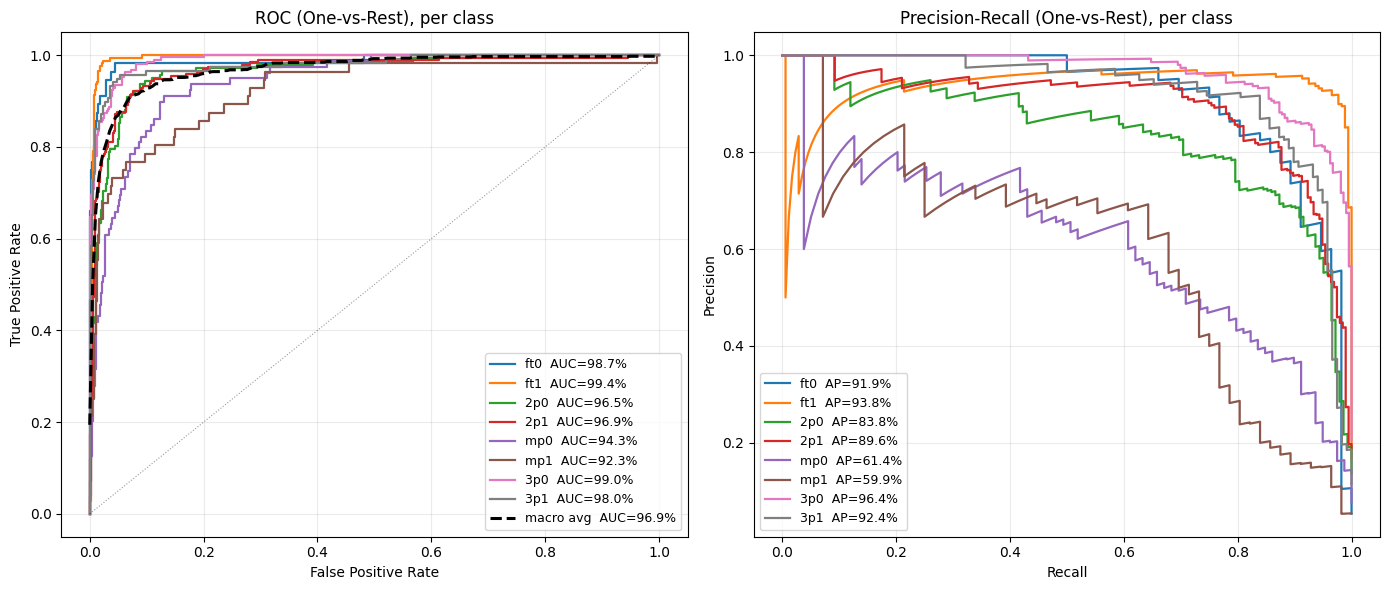

Saved /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/base/eval_report/roc_pr_curves.png


In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
)

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))

fpr_grid = np.linspace(0, 1, 200)
tpr_interp_stack = []

for c_idx_order, c_idx in enumerate(ORDER_IDX):
    y_true_c = (labels == c_idx).astype(np.int64)
    y_score_c = probs[:, c_idx]
    if y_true_c.sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
    auc = roc_auc_score(y_true_c, y_score_c)
    ax_roc.plot(fpr, tpr, lw=1.6, label=f'{CLASS_NAMES[c_idx]}  AUC={auc*100:.1f}%')
    tpr_interp_stack.append(np.interp(fpr_grid, fpr, tpr))

    prec, rec, _ = precision_recall_curve(y_true_c, y_score_c)
    ap = average_precision_score(y_true_c, y_score_c)
    ax_pr.plot(rec, prec, lw=1.6, label=f'{CLASS_NAMES[c_idx]}  AP={ap*100:.1f}%')

if tpr_interp_stack:
    macro_tpr = np.mean(np.vstack(tpr_interp_stack), axis=0)
    macro_auc = float(np.trapz(macro_tpr, fpr_grid))
    ax_roc.plot(fpr_grid, macro_tpr, 'k--', lw=2.2, label=f'macro avg  AUC={macro_auc*100:.1f}%')

ax_roc.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.4)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC (One-vs-Rest), per class')
ax_roc.legend(loc='lower right', fontsize=9)
ax_roc.grid(alpha=0.25)

ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall (One-vs-Rest), per class')
ax_pr.legend(loc='lower left', fontsize=9)
ax_pr.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(REPORT_DIR / 'roc_pr_curves.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved {REPORT_DIR/"roc_pr_curves.png"}')

## 18. Feature separability — t-SNE colored by each taxonomy

Using the pooled backbone embedding (same tensor the classifier head sees), project to 2-D with t-SNE and color by three different palettes so we can see *what kind of structure* the representations have learned:

- **By 8-class label** — the fully-fine-grained view (same as `tsne_after.png` from earlier eval).
- **By shot type** — does the model cluster by attempt type?
- **By make/miss** — does it cluster by outcome?

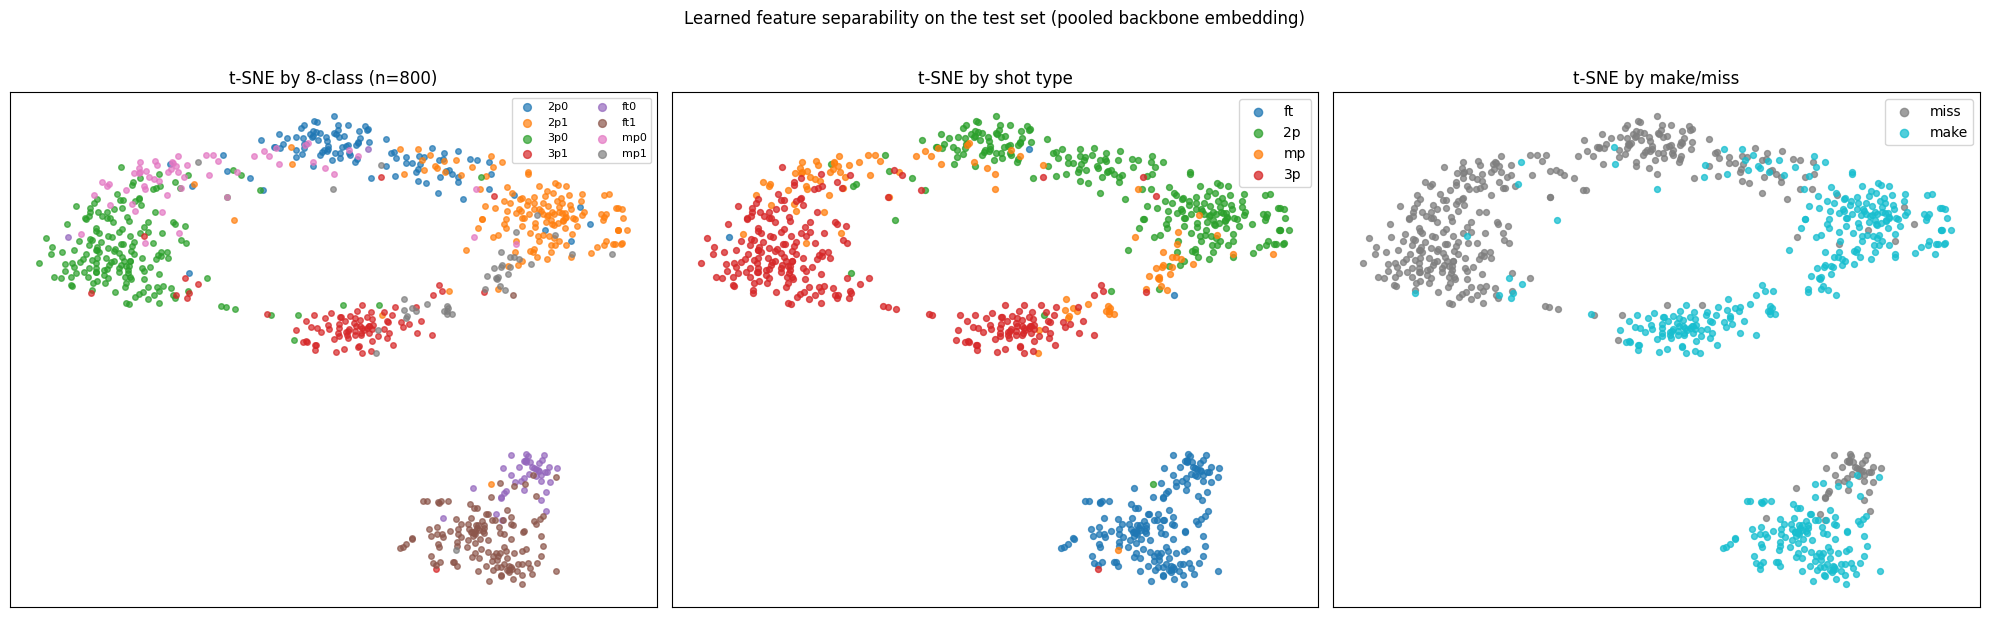

Saved /content/drive/MyDrive/Courses/Spring 1/Applied Computer Vision/Project/Test/runs/base/eval_report/tsne_taxonomies.png


In [ ]:
from sklearn.manifold import TSNE

TSNE_MAX = min(800, features.shape[0])
rng = np.random.default_rng(0)
sel = rng.choice(features.shape[0], size=TSNE_MAX, replace=False)

perplexity = float(min(30, max(5, TSNE_MAX // 10)))
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=0,
            init='pca', learning_rate='auto')
emb = tsne.fit_transform(features[sel])

lbl_sel        = labels[sel]
shot_sel       = true_shot_type[sel]
outcome_sel    = true_outcome[sel]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax = axes[0]
for c_idx, name in enumerate(CLASS_NAMES):
    m = lbl_sel == c_idx
    if m.any():
        ax.scatter(emb[m, 0], emb[m, 1], s=16, alpha=0.7, label=name)
ax.set_title(f't-SNE by 8-class (n={TSNE_MAX})')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='best', fontsize=8, markerscale=1.4, ncol=2)

ax = axes[1]
shot_colors = {'ft': '#1f77b4', '2p': '#2ca02c', 'mp': '#ff7f0e', '3p': '#d62728'}
for idx, name in enumerate(SHOT_TYPES):
    m = shot_sel == idx
    if m.any():
        ax.scatter(emb[m, 0], emb[m, 1], s=18, alpha=0.75, color=shot_colors[name], label=name)
ax.set_title('t-SNE by shot type')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='best', fontsize=10, markerscale=1.4)

ax = axes[2]
outcome_colors = {'miss': '#7f7f7f', 'make': '#17becf'}
for idx, name in enumerate(OUTCOMES):
    m = outcome_sel == idx
    if m.any():
        ax.scatter(emb[m, 0], emb[m, 1], s=18, alpha=0.75, color=outcome_colors[name], label=name)
ax.set_title('t-SNE by make/miss')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='best', fontsize=10, markerscale=1.4)

fig.suptitle('Learned feature separability on the test set (pooled backbone embedding)', y=1.02)
fig.tight_layout()
fig.savefig(REPORT_DIR / 'tsne_taxonomies.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved {REPORT_DIR/"tsne_taxonomies.png"}')